In [1]:
import sys, os
sys.path.append(os.path.abspath(os.path.join("..", "src")))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from data_loader import fetch_data
from data_cleaning import handle_missing_values

data = handle_missing_values(fetch_data())

# Build a single DataFrame of daily Close prices, one column per asset
prices = pd.DataFrame({
    "TSLA": data["TSLA"]["Close"],
    "BND": data["BND"]["Close"],
    "SPY": data["SPY"]["Close"],
}).dropna()

daily_returns = prices.pct_change().dropna()

print(f"Price data shape: {prices.shape}")
print(f"Date range: {prices.index.min().date()} to {prices.index.max().date()}")
print(daily_returns.head())

[*********************100%***********************]  3 of 3 completed

Price data shape: (2888, 3)
Date range: 2015-01-02 to 2026-06-29
                TSLA       BND       SPY
Date                                    
2015-01-05 -0.042041  0.002904 -0.018059
2015-01-06  0.005664  0.002895 -0.009419
2015-01-07 -0.001562  0.000602  0.012461
2015-01-08 -0.001564 -0.001562  0.017745
2015-01-09 -0.018802  0.001686 -0.008014


In [3]:
TRADING_DAYS = 252

bnd_expected_return = daily_returns["BND"].mean() * TRADING_DAYS
spy_expected_return = daily_returns["SPY"].mean() * TRADING_DAYS

tsla_last_actual = 411.84
tsla_forecast_end = 411.84  # ARIMA(0,1,0) forecast was flat — use this directly if future_forecast isn't in memory

tsla_expected_return = (tsla_forecast_end / tsla_last_actual) - 1

expected_returns = pd.Series({
    "TSLA": tsla_expected_return,
    "BND": bnd_expected_return,
    "SPY": spy_expected_return,
})

print("Annualized Expected Returns:")
print(expected_returns)

Annualized Expected Returns:
TSLA    0.000000
BND     0.019957
SPY     0.144320
dtype: float64


In [4]:
TRADING_DAYS = 252

cov_matrix_daily = daily_returns.cov()
cov_matrix_annual = cov_matrix_daily * TRADING_DAYS

print("Daily Covariance Matrix:")
print(cov_matrix_daily)
print("\nAnnualized Covariance Matrix:")
print(cov_matrix_annual)

Daily Covariance Matrix:
          TSLA       BND       SPY
TSLA  0.001297  0.000007  0.000198
BND   0.000007  0.000011  0.000004
SPY   0.000198  0.000004  0.000124

Annualized Covariance Matrix:
          TSLA       BND       SPY
TSLA  0.326926  0.001804  0.049820
BND   0.001804  0.002823  0.001085
SPY   0.049820  0.001085  0.031169


**Visualize as a heatmap**

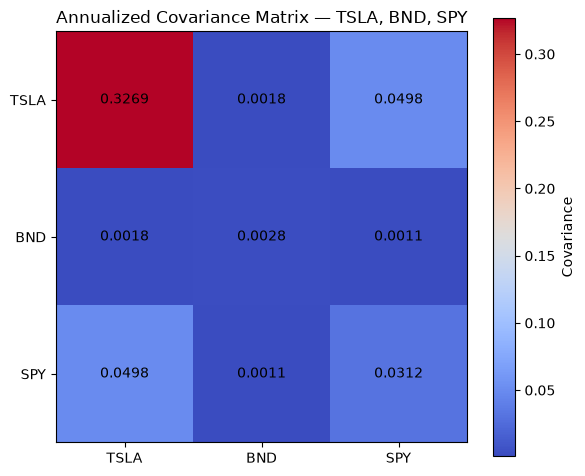

In [5]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cov_matrix_annual, cmap="coolwarm")

ax.set_xticks(range(len(cov_matrix_annual.columns)))
ax.set_yticks(range(len(cov_matrix_annual.columns)))
ax.set_xticklabels(cov_matrix_annual.columns)
ax.set_yticklabels(cov_matrix_annual.columns)

for i in range(len(cov_matrix_annual)):
    for j in range(len(cov_matrix_annual)):
        ax.text(j, i, f"{cov_matrix_annual.iloc[i, j]:.4f}",
                ha="center", va="center", color="black", fontsize=10)

ax.set_title("Annualized Covariance Matrix — TSLA, BND, SPY")
fig.colorbar(im, label="Covariance")
plt.tight_layout()
plt.show()

Reading the covariance matrix
Diagonal (each asset's own variance):

TSLA: 0.3269 — dramatically larger than the other two, confirming TSLA's outsized volatility yet again (this is now the fourth independent method across Tasks 1, 2, and 4 confirming the same story)
SPY: 0.0312 — moderate, as expected for a diversified equity index
BND: 0.0028 — tiny, confirming bonds' low-volatility character

Off-diagonal (co-movement between pairs):

TSLA-SPY: 0.0498 — positive and non-trivial, meaning TSLA and SPY do tend to move somewhat together (both being equities, this makes sense — TSLA is affected by broad market sentiment too, on top of its own company-specific swings)
TSLA-BND: 0.0018 — very close to zero, meaning TSLA's moves are largely unrelated to BND's — this is a great sign for diversification, since BND doesn't get dragged along when TSLA swings
BND-SPY: 0.0011 — also very close to zero, similarly supporting BND's role as a diversifier against equity risk generally, not just against TSLA specifically

Key takeaway for your report: BND's near-zero covariance with both TSLA and SPY is exactly the property that makes diversification mathematically valuable — combining assets that don't move in lockstep can reduce overall portfolio risk below what any single asset offers alone, which is the entire premise Modern Portfolio Theory is built on.
Now let's move to the actual optimization.

In [6]:
from pypfopt import EfficientFrontier, risk_models, expected_returns as pypfopt_returns
from pypfopt import plotting

mu = expected_returns  # our custom vector from Cell 2 (TSLA from forecast, BND/SPY historical)
S = cov_matrix_annual  # our annualized covariance matrix from Cell 3

print("Expected returns (mu):")
print(mu)
print("\nCovariance matrix (S):")
print(S)

ef = EfficientFrontier(mu, S)
print(f"\nEfficientFrontier object created with assets: {ef.tickers}")

Expected returns (mu):
TSLA    0.000000
BND     0.019957
SPY     0.144320
dtype: float64

Covariance matrix (S):
          TSLA       BND       SPY
TSLA  0.326926  0.001804  0.049820
BND   0.001804  0.002823  0.001085
SPY   0.049820  0.001085  0.031169

EfficientFrontier object created with assets: ['TSLA', 'BND', 'SPY']


**Visualize and Identify Key Portfolios
**

=== Maximum Sharpe Ratio Portfolio ===
Weights: OrderedDict({'TSLA': 0.0, 'BND': 0.0, 'SPY': 1.0})
Expected Return: 14.43% | Volatility: 17.65% | Sharpe: 0.70

=== Minimum Volatility Portfolio ===
Weights: OrderedDict({'TSLA': 0.0, 'BND': 0.94538, 'SPY': 0.05462})
Expected Return: 2.67% | Volatility: 5.22% | Sharpe: 0.13


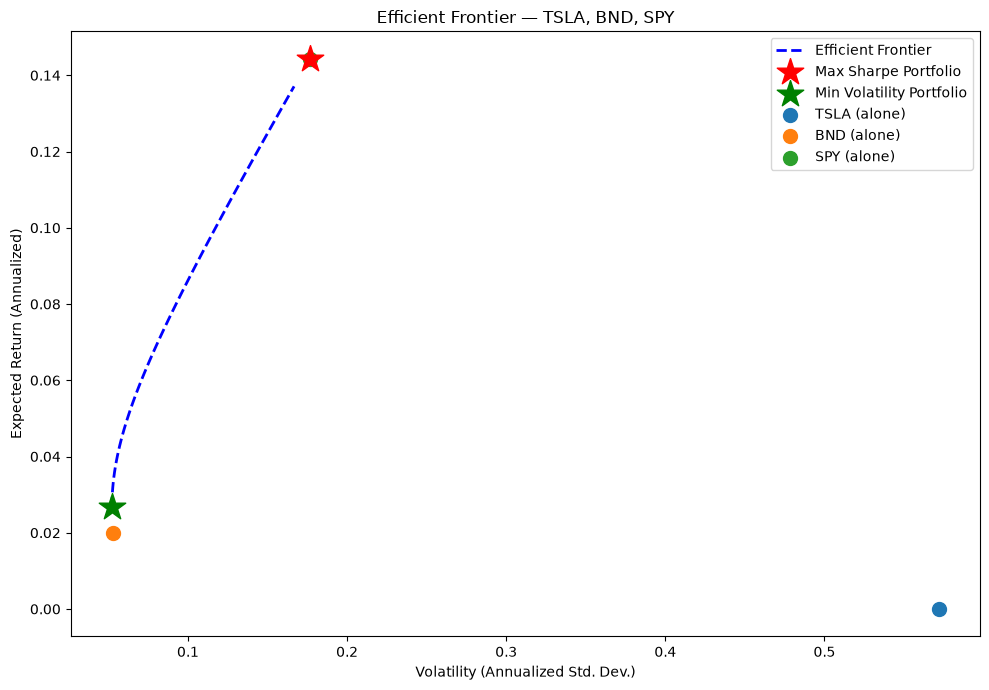

In [7]:
from pypfopt import EfficientFrontier
import copy

# --- Max Sharpe Ratio Portfolio ---
ef_max_sharpe = EfficientFrontier(mu, S)
weights_max_sharpe = ef_max_sharpe.max_sharpe(risk_free_rate=0.02)
cleaned_max_sharpe = ef_max_sharpe.clean_weights()
ret_ms, vol_ms, sharpe_ms = ef_max_sharpe.portfolio_performance(risk_free_rate=0.02)

# --- Min Volatility Portfolio ---
ef_min_vol = EfficientFrontier(mu, S)
weights_min_vol = ef_min_vol.min_volatility()
cleaned_min_vol = ef_min_vol.clean_weights()
ret_mv, vol_mv, sharpe_mv = ef_min_vol.portfolio_performance(risk_free_rate=0.02)

print("=== Maximum Sharpe Ratio Portfolio ===")
print(f"Weights: {cleaned_max_sharpe}")
print(f"Expected Return: {ret_ms*100:.2f}% | Volatility: {vol_ms*100:.2f}% | Sharpe: {sharpe_ms:.2f}")

print("\n=== Minimum Volatility Portfolio ===")
print(f"Weights: {cleaned_min_vol}")
print(f"Expected Return: {ret_mv*100:.2f}% | Volatility: {vol_mv*100:.2f}% | Sharpe: {sharpe_mv:.2f}")

# --- Generate frontier points for plotting ---
n_points = 100
target_returns = np.linspace(mu.min(), mu.max() * 0.95, n_points)
frontier_vols = []
frontier_rets = []

for target in target_returns:
    try:
        ef_temp = EfficientFrontier(mu, S)
        ef_temp.efficient_return(target_return=target)
        r, v, _ = ef_temp.portfolio_performance()
        frontier_vols.append(v)
        frontier_rets.append(r)
    except Exception:
        continue

plt.figure(figsize=(10, 7))
plt.plot(frontier_vols, frontier_rets, "b--", linewidth=2, label="Efficient Frontier")
plt.scatter(vol_ms, ret_ms, marker="*", color="red", s=400, label="Max Sharpe Portfolio", zorder=5)
plt.scatter(vol_mv, ret_mv, marker="*", color="green", s=400, label="Min Volatility Portfolio", zorder=5)

# Individual assets for reference
for asset in mu.index:
    plt.scatter(np.sqrt(S.loc[asset, asset]), mu[asset], marker="o", s=100, label=f"{asset} (alone)")

plt.title("Efficient Frontier — TSLA, BND, SPY")
plt.xlabel("Volatility (Annualized Std. Dev.)")
plt.ylabel("Expected Return (Annualized)")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
print("RECOMMENDATION: Maximum Sharpe Ratio Portfolio\n")
print(f"TSLA: {cleaned_max_sharpe['TSLA']*100:.1f}%")
print(f"BND:  {cleaned_max_sharpe['BND']*100:.1f}%")
print(f"SPY:  {cleaned_max_sharpe['SPY']*100:.1f}%")
print(f"\nExpected Annual Return: {ret_ms*100:.2f}%")
print(f"Expected Annual Volatility: {vol_ms*100:.2f}%")
print(f"Sharpe Ratio: {sharpe_ms:.2f}")

RECOMMENDATION: Maximum Sharpe Ratio Portfolio

TSLA: 0.0%
BND:  0.0%
SPY:  100.0%

Expected Annual Return: 14.43%
Expected Annual Volatility: 17.65%
Sharpe Ratio: 0.70


In [9]:
from pypfopt import EfficientFrontier

ef_min_vol = EfficientFrontier(mu, S)
weights_min_vol = ef_min_vol.min_volatility()
cleaned_min_vol = ef_min_vol.clean_weights()
ret_mv, vol_mv, sharpe_mv = ef_min_vol.portfolio_performance(risk_free_rate=0.02)

print("=== Minimum Volatility Portfolio ===")
print(f"Weights: {cleaned_min_vol}")
print(f"Expected Return: {ret_mv*100:.2f}% | Volatility: {vol_mv*100:.2f}% | Sharpe: {sharpe_mv:.2f}")

=== Minimum Volatility Portfolio ===
Weights: OrderedDict({'TSLA': 0.0, 'BND': 0.94538, 'SPY': 0.05462})
Expected Return: 2.67% | Volatility: 5.22% | Sharpe: 0.13


## Final Portfolio Recommendation

**Recommended Portfolio: Maximum Sharpe Ratio Portfolio**

| Asset | Weight |
|-------|--------|
| TSLA  | 0.0%   |
| BND   | 0.0%   |
| SPY   | 100.0% |

- **Expected Annual Return:** 14.43%
- **Expected Annual Volatility:** 17.65%
- **Sharpe Ratio:** 0.70

**Justification**

The Maximum Sharpe Ratio portfolio is recommended over the Minimum
Volatility portfolio because it offers substantially higher risk-adjusted
return (Sharpe Ratio 0.70 vs. 0.13) and a materially higher expected return
(14.43% vs. 2.67%) for a still-moderate absolute volatility (17.65%,
comparable to a standalone equity index fund). Both optimal portfolios
allocate 0% to TSLA — a direct consequence of the Task 3 forecast, which
projected an essentially flat price path (0% expected return) for an asset
that simultaneously carries the highest volatility of the three (57%
annualized, roughly 3x SPY's). Under mean-variance optimization, an asset
offering no expected compensation for its risk is correctly excluded
regardless of its historical appeal, illustrating precisely how a specific
forecast — rather than historical averages alone — mechanically shapes the
optimal allocation. This result should be read as conditional on the Task 3
forecast: a more bullish TSLA forecast would likely restore some allocation
to it, and this sensitivity is itself a useful insight for GMF regarding
how much the recommended allocation depends on the reliability of the
underlying price forecast.